In [4]:
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import pandas as pd

In [13]:
D0 = "2005-01-03"
D1 = "2024-12-31"

rd = pd.read_parquet("./return/return_d.parquet").loc[D0:D1]
rf = pd.read_parquet("./return/ffr_d.parquet").reindex(rd.index)
rd.shape, rf.shape

((5033, 44), (5033, 1))

In [26]:
def sharpe_geom(rd: pd.DataFrame, rf: pd.Series):
    assert rd.shape[0] == rf.shape[0]
    num_days = rd.notna().sum(axis=0)
    rd_ = rd.fillna(0.0)
    rf_ = rf.fillna(0.0).values
    ret_ann = ((rd_+1.0).prod() / (rf_+1.0).prod()) ** (252 / num_days) - 1.0
    vol_ann = rd_.std() * np.sqrt(252)
    return ret_ann / vol_ann

In [27]:
rx = rd.sub(rf.values, axis=0)
rf_ann = (1.0+rf).prod() ** (252 / rf.shape[0]) - 1.0
na_count = rd.notna().sum(axis=0)

sharpe = sharpe_geom(rd, rf)
ret_ann = (1.0+rd).prod() ** (252 / na_count)-1.0
vol_ann = rd.std() * np.sqrt(252)
ret_tot = (1.0+rd).prod()-1.0

stats = pd.DataFrame({
    "sharpe": sharpe,
    "ret ann": ret_ann,
    "vol ann": vol_ann,
    "ret tot": ret_tot,
}, index=rd.columns)

stats.sort_values(by="sharpe", ascending=False)

,sharpe,ret ann,vol ann,ret tot
Ticker,,,,
BTC-USD,1.086222,0.528293,0.700947,21.093811
QQQ,0.585891,0.144971,0.215396,13.936729
XLK,0.559025,0.142343,0.221124,13.266696
XLP,0.520728,0.091304,0.140980,4.726174
XLV,0.476867,0.097317,0.166348,5.390293
SPY,0.445346,0.102845,0.190333,6.064992
XLY,0.424206,0.110948,0.218605,7.177201
GLD,0.407579,0.089382,0.175479,4.528082
XLU,0.376562,0.088618,0.187937,4.451160


In [ ]:
ret_d[["SPY", "EWJ", "EWG", "EWU", "EWL", "EWC", "XLK", "XLV", "XLF", "XLY", "XLI", "XLP"]].corr()


Ticker,SPY,EWJ,EWG,EWU,EWL,EWC,XLK,XLV,XLF,XLY,XLI,XLP
Ticker,,,,,,,,,,,,
SPY,1.000000,0.640749,0.756284,0.745212,0.655768,0.701390,0.869795,0.779706,0.827292,0.859126,0.882624,0.675569
EWJ,0.640749,1.000000,0.621385,0.605395,0.550362,0.541152,0.602821,0.533287,0.571315,0.594611,0.625873,0.447012
EWG,0.756284,0.621385,1.000000,0.796953,0.743357,0.672531,0.660450,0.609735,0.670471,0.685454,0.736735,0.522768
EWU,0.745212,0.605395,0.796953,1.000000,0.729645,0.688260,0.619335,0.618086,0.681874,0.659367,0.731467,0.544958
EWL,0.655768,0.550362,0.743357,0.729645,1.000000,0.596675,0.546934,0.563719,0.600049,0.600120,0.639697,0.509663
EWC,0.701390,0.541152,0.672531,0.688260,0.596675,1.000000,0.604957,0.535592,0.625208,0.606199,0.692595,0.428810
XLK,0.869795,0.602821,0.660450,0.619335,0.546934,0.604957,1.000000,0.648131,0.626353,0.735859,0.727747,0.462773
XLV,0.779706,0.533287,0.609735,0.618086,0.563719,0.535592,0.648131,1.000000,0.623051,0.665025,0.707049,0.612564
XLF,0.827292,0.571315,0.670471,0.681874,0.600049,0.625208,0.626353,0.623051,1.000000,0.737873,0.782282,0.573381


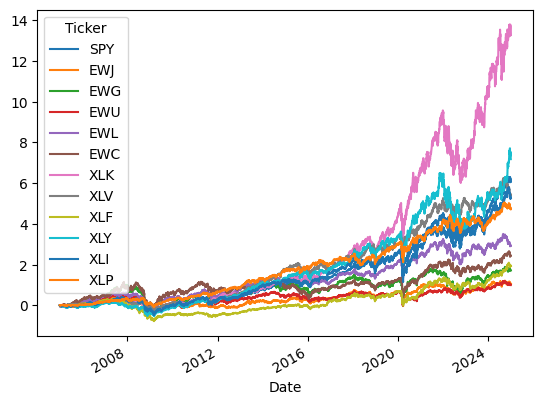

In [ ]:
((ret_d[["SPY", "EWJ", "EWG", "EWU", "EWL", "EWC", "XLK", "XLV", "XLF", "XLY", "XLI", "XLP"]].loc[D0:D1]+1.0).cumprod()-1.0).plot(legend=True)


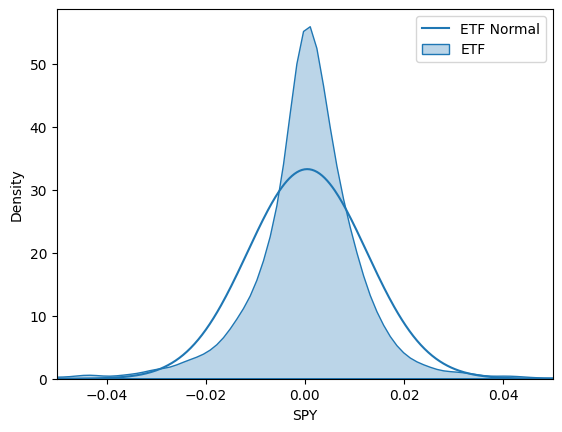

(np.float64(0.00046231960860153916), np.float64(0.01198871671515105))

In [10]:
D0 = "2005-01-03"
D1 = "2010-01-03"
D2 = "2015-01-03"
D3 = "2020-01-03"
D4 = "2025-01-03"

etf = ret_d["SPY"].loc[D0:D4]
mu = etf.mean()
sigma = etf.std()

norm_pdf = lambda x: 1/np.sqrt(2*np.pi*sigma**2) * np.exp(-0.5 * (x - mu)**2 / sigma**2)
x = np.linspace(etf.min(), etf.max(), 1000)

plt.plot(x, norm_pdf(x), label="ETF Normal")
sns.kdeplot(etf, label="ETF", fill=True, alpha=0.3)
plt.xlim(-0.05, 0.05)
plt.legend()
plt.show()
mu, sigma

In [ ]:
# NOTE Regress Sectors and International ETFs on market (potentially gold and bonds as well)
# Rank idiosyncratic returns to get assets that perform well orthogonally to the market
# Otherwise predictor may rank which ETF has biggest market component

# Ai = B * SPY + ei
# ei = Ai - B * SPY
spy = rd["SPY"]
Am  = rd.drop(columns="SPY")
Be = Am.mul(spy, axis=0).sum(axis=0) / (spy @ spy)
eps = Am.sub(Be.values[None, :] * spy.values[:, None])
Be.sort_values()

Ticker
TLT       -0.250879
TIP       -0.036011
AGG       -0.002474
WEAT       0.028987
GLD        0.053567
SOYB       0.076818
CORN       0.079064
LQD        0.085502
CANE       0.094286
UNG        0.222676
CPER       0.225270
DBA        0.242571
PPLT       0.263119
BTC-USD    0.356373
SLV        0.359491
DBC        0.399731
DBB        0.428582
XLP        0.570542
XLU        0.650593
USO        0.673890
XLV        0.716780
EWL        0.799793
EWJ        0.808476
IBB        0.883703
EWH        0.897500
EWS        0.920996
WOOD       0.929509
EWC        0.939361
EWT        0.952480
EWU        0.995384
XLI        0.996901
XLY        1.029899
QQQ        1.038804
XLB        1.058012
XLK        1.062233
EWW        1.079066
EWG        1.091074
EWP        1.092508
IWM        1.138148
IYR        1.138834
XLE        1.154056
EWA        1.172603
EWY        1.193762
EEM        1.212638
EWD        1.236201
XLF        1.309507
EWZ        1.355571
dtype: float64

In [ ]:
# timeline = pd.date_range(start=D0, end=D1)
# day_of_wk = np.cos(2*np.pi / 7 * timeline.day_of_week)
# day_of_mt = np.cos(2*np.pi / 31 * timeline.day)
# day_of_yr = np.cos(2*np.pi / 365 * timeline.day_of_year)